# 1.b - Numerical Differentiation

In [1]:
import sys
import numpy as np

def diff_forward(f, x: float, h: float=np.sqrt(sys.float_info.epsilon)) -> float:
    return (f(x+h) - f(x))/h

def diff_central(f, x: float, h: float=np.cbrt(sys.float_info.epsilon)) -> float:
    return (f(x+h/2) - f(x-h/2))/h

def diff_backward(f, x: float,  h: float=np.sqrt(sys.float_info.epsilon)) -> float:
    return (f(x) - f(x-h))/h


In [2]:
import math

def f1(x):
    return x**3 -2*(x**2) + 3*x -5

def f2(x):
    return math.exp(x) * math.sin(x)

def f3(x):
    return 1 / (1 + (x**2))

x0 = 1
print(f"Numerical derivatives of the first function at x = {x0}: \n Forward: {diff_forward(f1, x0, h = 10**(-5))}; \n Central: {diff_central(f1, x0, h = 10**(-5))}; \n Backward: {diff_backward(f1, x0, h = 10**(-5))}")
print(f"Numerical derivatives of the second function at x = {x0}: \n Forward: {diff_forward(f2, x0, h = 10**(-5))}; \n Central: {diff_central(f2, x0, h = 10**(-5))}; \n Backward: {diff_backward(f2, x0, h = 10**(-5))}")
print(f"Numerical derivatives of the third function at x = {x0}: \n Forward: {diff_forward(f3, x0, h = 10**(-5))}; \n Central: {diff_central(f3, x0, h = 10**(-5))}; \n Backward: {diff_backward(f3, x0, h = 10**(-5))}")


Numerical derivatives of the first function at x = 1: 
 Forward: 2.0000100001027477; 
 Central: 2.0000000001019203; 
 Backward: 1.9999900001010926
Numerical derivatives of the second function at x = 1: 
 Forward: 3.7560639140288283; 
 Central: 3.756049227154889; 
 Backward: 3.756034540103314
Numerical derivatives of the third function at x = 1: 
 Forward: -0.4999975000030687; 
 Central: -0.5000000000032756; 
 Backward: -0.5000024999923802


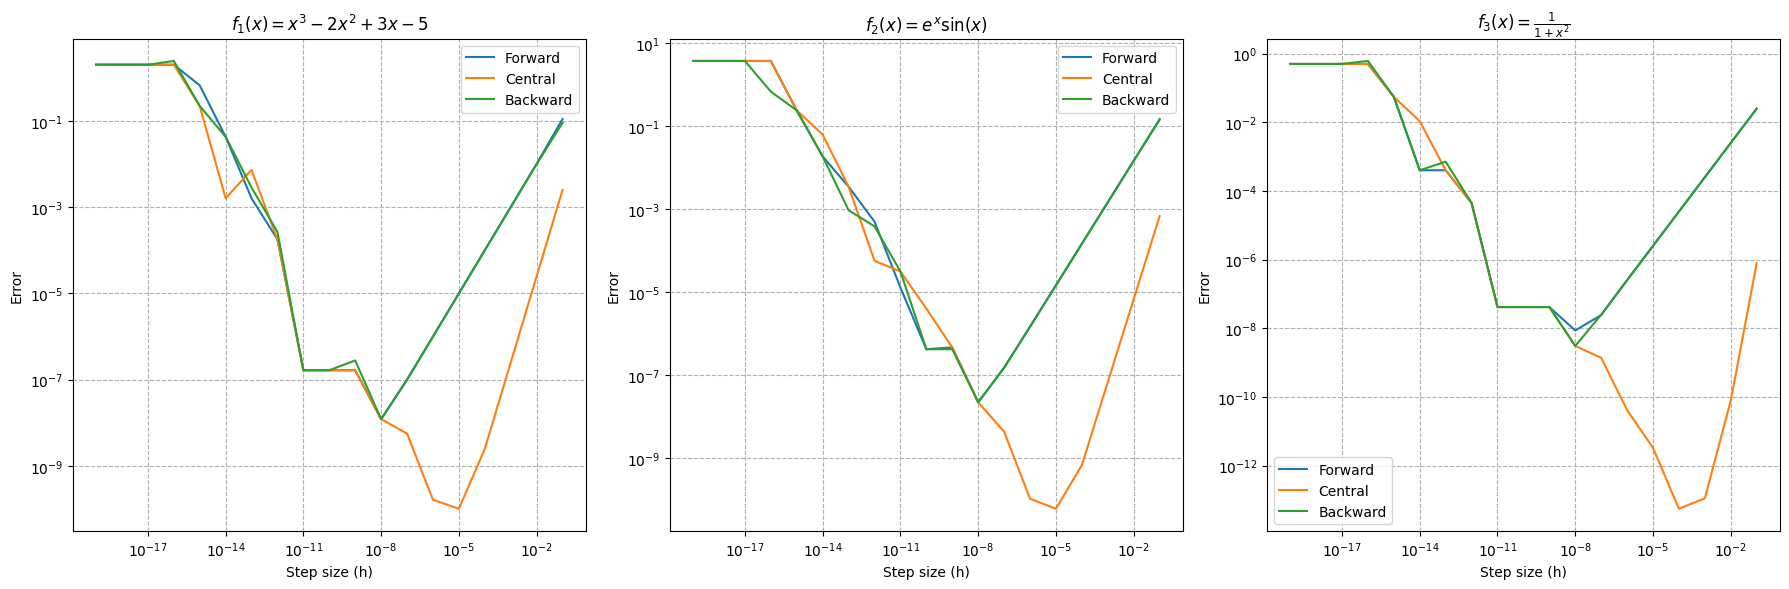

In [3]:
import matplotlib.pyplot as plt

anres1 = 2
anres2 = math.exp(1)*(math.sin(1) + math.cos(1))
anres3 = -0.5

h_val = [10**(-1), 10**(-2), 10**(-3), 10**(-4), 10**(-5), 10**(-6), 10**(-7), 10**(-8), 10**(-9), 10**(-10),
         10**(-11), 10**(-12), 10**(-13), 10**(-14), 10**(-15), 10**(-16), 10**(-17), 10**(-18), 10**(-19),]

err_res_for1, err_res_cen1, err_res_back1 = [], [], []
err_res_for2, err_res_cen2, err_res_back2 = [], [], []
err_res_for3, err_res_cen3, err_res_back3 = [], [], []
for step in h_val:
    # Forward difference errors
    err_res_for1.append(abs(anres1 - diff_forward(f1, x0, step)))
    err_res_for2.append(abs(anres2 - diff_forward(f2, x0, step)))
    err_res_for3.append(abs(anres3 - diff_forward(f3, x0, step)))
    
    # Central difference errors
    err_res_cen1.append(abs(anres1 - diff_central(f1, x0, step)))
    err_res_cen2.append(abs(anres2 - diff_central(f2, x0, step)))
    err_res_cen3.append(abs(anres3 - diff_central(f3, x0, step)))

    # Backward difference errors
    err_res_back1.append(abs(anres1 - diff_backward(f1, x0, step)))
    err_res_back2.append(abs(anres2 - diff_backward(f2, x0, step)))
    err_res_back3.append(abs(anres3 - diff_backward(f3, x0, step)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = [r"$f_1(x) = x^3 -2x^2+3x-5$", r"$f_2(x) = e^x \sin(x)$", r"$f_3(x) = \frac{1}{1+x^2}$"]
error_data = [
    (err_res_for1, err_res_cen1, err_res_back1),
    (err_res_for2, err_res_cen2, err_res_back2),
    (err_res_for3, err_res_cen3, err_res_back3),
]
for i, ax in enumerate(axes):
    ax.loglog(h_val, error_data[i][0], label="Forward")
    ax.loglog(h_val, error_data[i][1], label="Central")
    ax.loglog(h_val, error_data[i][2], label="Backward")
    ax.set_xlabel("Step size (h)")
    ax.set_ylabel("Error")
    ax.set_title(titles[i])
    ax.legend()
    ax.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()


# 1.c - Automatic Differentiation

In [107]:
from typing import Union
import math  

class Var:
    """
    A variable which holds a number and enables gradient computations.
    """

    def __init__(self, val: Union[float, int], parents=None, op = ""):
        assert type(val) in {float, int}
        if parents is None:
            parents = []
        self.v = val
        self.parents = parents
        self.grad = 0.0
        self.op = op  # Operation that produced this variable

    def backprop(self, bp):
        self.grad += bp
        for parent, grad in self.parents:
            parent.backprop(grad * bp)

    def backward(self):
        self.backprop(1.0)

    def __add__(self, other):
        if isinstance(other, (int, float)):  # Support scalar addition
            other = Var(other)
        return Var(self.v + other.v, [(self, 1.0), (other, 1.0)])

    def __mul__(self, other):
        if isinstance(other, (int, float)):  # Support scalar multiplication
            other = Var(other)
        return Var(self.v * other.v, [(self, other.v), (other, self.v)])

    def __pow__(self, power: Union[float, int]) -> 'Var':
        assert type(power) in {float, int}, "power must be float or int"
        return Var(self.v ** power, [(self, power * self.v ** (power - 1))])

    def __neg__(self):
        return Var(-1.0) * self

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        if isinstance(other, (int, float)):  # Support scalar division
            other = Var(other)
        return self * other ** -1

    def tanh(self):
        return Var(math.tanh(self.v), [(self, 1 - math.tanh(self.v) ** 2)])

    def relu(self):
        return Var(self.v if self.v > 0.0 else 0.0, [(self, 1.0 if self.v > 0.0 else 0.0)])

    def exp(self):
        return Var(math.exp(self.v), [(self, math.exp(self.v))])  # Fix NameError

    def sin(self):
        return Var(math.sin(self.v), [(self, math.cos(self.v))])  # Fix NameError

    def __repr__(self):
        return "Var(v=%.4f, grad=%.4f)" % (self.v, self.grad)

#evaluation point
x0 = Var(1.0)

#functions
f1 = x0**3 - Var(2) * (x0**2) + Var(3) * x0 - Var(5)  

f2 = x0.exp() * x0.sin()  
f3 = Var(1) / (Var(1) + (x0**2))  

#derivatives
f1.backward()
auto_f1 = x0.grad
print(f"Automatic derivative of the first function at x = {x0}: {auto_f1}")

x0.grad = 0  
f2.backward()
auto_f2 = x0.grad
print(f"Automatic derivative of the second function at x = {x0}: {auto_f2}")

x0.grad = 0  
f3.backward()
auto_f3 = x0.grad
print(f"Automatic derivative of the third function at x = {x0}: {auto_f3}")


Automatic derivative of the first function at x = Var(v=1.0000, grad=2.0000): 2.0
Automatic derivative of the second function at x = Var(v=1.0000, grad=3.7560): 3.7560492270947274
Automatic derivative of the third function at x = Var(v=1.0000, grad=-0.5000): -0.5


In [ ]:
# Errors between automatic and analytical differentiatiop methods

errors = [
    abs(auto_f1 - anres1),
    abs(auto_f2 - anres2),
    abs(auto_f3 - anres3)
]
print(errors)

[0.0, 0.0, 0.0]


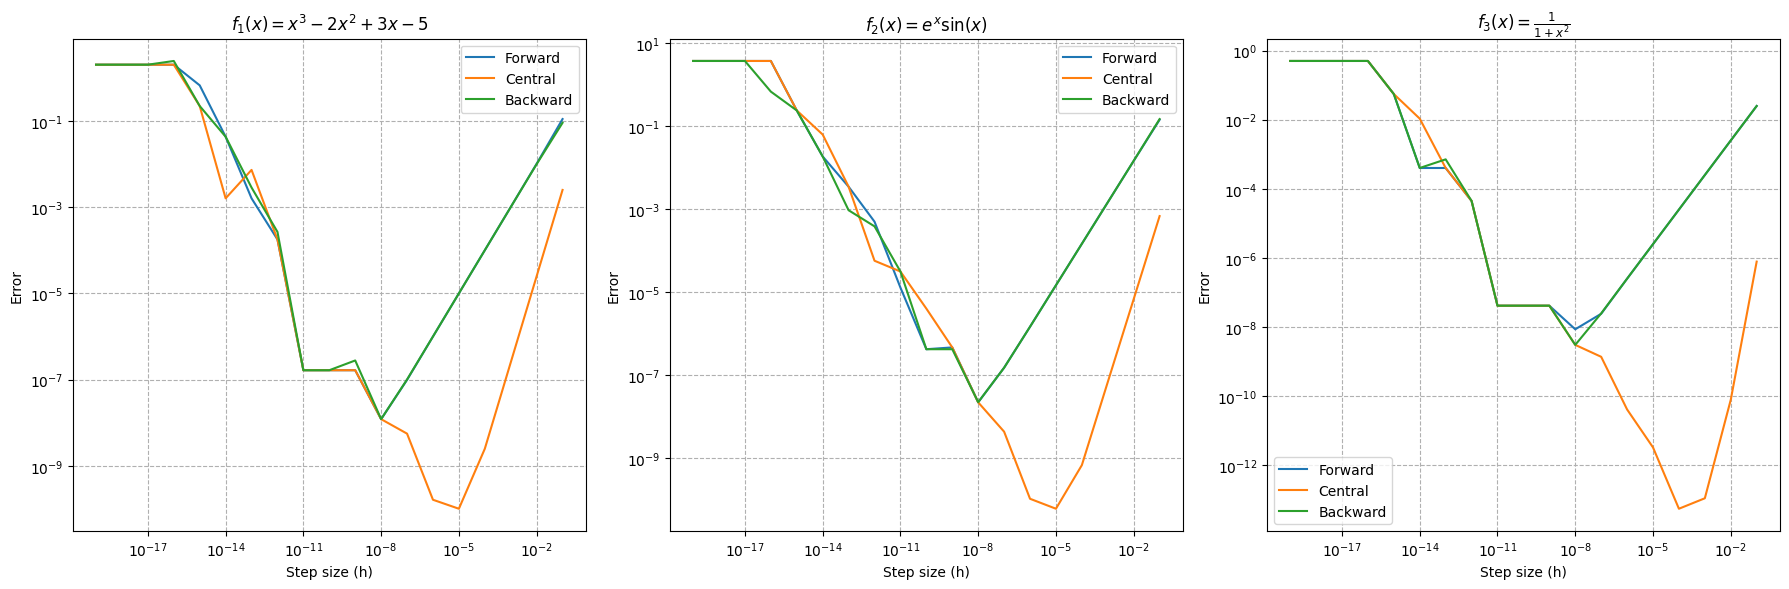

In [ ]:
#error between automatic and numerical differentitaion as step size increase 

# Define step sizes
h_val = [10**(-1), 10**(-2), 10**(-3), 10**(-4), 10**(-5), 10**(-6), 10**(-7), 10**(-8), 10**(-9), 10**(-10),
         10**(-11), 10**(-12), 10**(-13), 10**(-14), 10**(-15), 10**(-16), 10**(-17), 10**(-18), 10**(-19)]

# Initialize lists to store error results
err_res_for1, err_res_cen1, err_res_back1 = [], [], []
err_res_for2, err_res_cen2, err_res_back2 = [], [], []
err_res_for3, err_res_cen3, err_res_back3 = [], [], []

# Loop through different step sizes
for step in h_val:
    # Forward difference errors
    err_res_for1.append(abs(auto_f1 - diff_forward(f1_var, x0, step).v))  # Ensure the result is a float
    err_res_for2.append(abs(auto_f2 - diff_forward(f2_var, x0, step).v))
    err_res_for3.append(abs(auto_f3 - diff_forward(f3_var, x0, step).v))
    
    # Central difference errors
    err_res_cen1.append(abs(auto_f1 - diff_central(f1_var, x0, step).v))  # Ensure the result is a float
    err_res_cen2.append(abs(auto_f2 - diff_central(f2_var, x0, step).v))
    err_res_cen3.append(abs(auto_f3 - diff_central(f3_var, x0, step).v))

    # Backward difference errors
    err_res_back1.append(abs(auto_f1 - diff_backward(f1_var, x0, step).v))  # Ensure the result is a float
    err_res_back2.append(abs(auto_f2 - diff_backward(f2_var, x0, step).v))
    err_res_back3.append(abs(auto_f3 - diff_backward(f3_var, x0, step).v))

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = [r"$f_1(x) = x^3 -2x^2+3x-5$", r"$f_2(x) = e^x \sin(x)$", r"$f_3(x) = \frac{1}{1+x^2}$"]
error_data = [
    (err_res_for1, err_res_cen1, err_res_back1),
    (err_res_for2, err_res_cen2, err_res_back2),
    (err_res_for3, err_res_cen3, err_res_back3),
]

for i, ax in enumerate(axes):
    ax.loglog(h_val, error_data[i][0], label="Forward")
    ax.loglog(h_val, error_data[i][1], label="Central")
    ax.loglog(h_val, error_data[i][2], label="Backward")
    ax.set_xlabel("Step size (h)")
    ax.set_ylabel("Error")
    ax.set_title(titles[i])
    ax.legend()
    ax.grid(True, which="both", linestyle="--")
plt.tight_layout()
plt.show()



In [ ]:
#computationla graph, at evaluation point x_0 = 1

from graphviz import Digraph

def generate_computational_graph(var):
    """
    Generates a structured computational graph with evaluation values and gradients.
    
    :param var: The root `Var` object (result of computation).
    :return: A Digraph object representing the computational graph.
    """
    graph = Digraph(format='png')
    node_set = set()

    def add_node(variable):
        """ Recursively add nodes and edges while preserving structure. """
        if id(variable) in node_set:
            return
        node_set.add(id(variable))

        # Node with value and gradient
        var_label = f"{variable.v:.4f}\n(grad={variable.grad:.4f})"
        graph.node(str(id(variable)), var_label, shape='ellipse', style='filled', fillcolor='lightblue')

        # Process parent nodes (input variables and operations)
        for parent, grad in variable.parents:
            if parent.op:  # Operation nodes (e.g., ×, +, ln)
                op_label = parent.op
                graph.node(str(id(parent)) + "_op", op_label, shape='circle', style='filled', fillcolor='lightgray')
                graph.edge(str(id(parent)), str(id(parent)) + "_op")  # Connect variable to op
                graph.edge(str(id(parent)) + "_op", str(id(variable)), label=f"{grad:.4f}")  # Op to result
            else:
                graph.edge(str(id(parent)), str(id(variable)), label=f"{grad:.4f}")
            
            # Recursively process parent nodes
            add_node(parent)

    add_node(var)  # Start from the root variable
    return graph

# Generate and render the graph for f1
graph_f1 = generate_computational_graph(f1)
graph_f1.render('Evaluated_computational_graph_f1', view=True)

graph_f2 = generate_computational_graph(f2)
graph_f2.render('Evaluated_computational_graph_f2', view=True)

graph_f3 = generate_computational_graph(f3)
graph_f3.render('Evaluated_computational_graph_f3', view=True)

'Evaluated_computational_graph_f3.png'

In [117]:
# theoretically computatioanl graph, obnly for functions, not for evaluation points

from graphviz import Digraph
import math

class Var:
    """Variable that holds a symbolic name and tracks operations for computational graph visualization."""

    def __init__(self, name, parents=None, op=""):
        """
        name: Symbolic name of the variable (e.g., 'x')
        parents: Parent nodes from which this variable is derived
        op: Operation used to obtain this variable
        """
        self.name = str(name)
        self.parents = parents if parents else []
        self.op = op  # Operation that produced this variable

    def __add__(self, other):
        other = Var(str(other)) if isinstance(other, (int, float)) else other
        return Var(f"({self.name} + {other.name})", [(self, "+"), (other, "+")], "+")

    def __mul__(self, other):
        other = Var(str(other)) if isinstance(other, (int, float)) else other
        return Var(f"({self.name} × {other.name})", [(self, "×"), (other, "×")], "×")

    def __pow__(self, power):
        assert isinstance(power, (int, float)), "Power must be int or float"
        return Var(f"({self.name} ** {power})", [(self, f"**{power}")], f"**{power}")

    def __neg__(self):
        return Var(f"(-{self.name})", [(self, "-")], "neg")

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        other = Var(str(other)) if isinstance(other, (int, float)) else other
        return Var(f"({self.name} / {other.name})", [(self, "/"), (other, "/")], "/")

    def exp(self):
        return Var(f"exp({self.name})", [(self, "exp")], "exp")

    def sin(self):
        return Var(f"sin({self.name})", [(self, "sin")], "sin")

    def __repr__(self):
        return f"Var(name={self.name})"
    
def generate_graph_f1():
    graph = Digraph(format='png')
    
    # Nodes
    graph.node('x0', 'x0', shape='ellipse')
    graph.node('2', '2', shape='ellipse')
    graph.node('3', '3', shape='ellipse')
    graph.node('5', '5', shape='ellipse')
    graph.node('c1', 'x^3', shape='circle')
    graph.node('c2', '×', shape='circle')  # Represents (-2 * x^2)
    graph.node('c3', '×', shape='circle')  # Represents (3 * x)
    graph.node('c4', '+', shape='circle')
    graph.node('c5', '-', shape='circle')
    
    # Edges
    graph.edge('x0', 'c1')
    graph.edge('x0', 'c2')
    graph.edge('2', 'c2')
    graph.edge('x0', 'c3')
    graph.edge('3', 'c3')
    graph.edge('c1', 'c4')
    graph.edge('c2', 'c4')
    graph.edge('c3', 'c4')
    graph.edge('c4', 'c5')
    graph.edge('5', 'c5')
    
    return graph

def generate_graph_f2():
    graph = Digraph(format='png')
    
    # Nodes
    graph.node('x0', 'x0', shape='ellipse')
    graph.node('exp', 'exp(x)', shape='circle')
    graph.node('sin', 'sin(x)', shape='circle')
    graph.node('c1', '×', shape='circle')
    
    # Edges
    graph.edge('x0', 'exp')
    graph.edge('x0', 'sin')
    graph.edge('exp', 'c1')
    graph.edge('sin', 'c1')
    
    return graph

def generate_graph_f3():
    graph = Digraph(format='png')
    
    # Nodes
    graph.node('x0', 'x0', shape='ellipse')
    graph.node('1', '1', shape='ellipse')
    graph.node('c1', 'x^2', shape='circle')
    graph.node('c2', '+', shape='circle')
    graph.node('c3', '1 / x', shape='circle')
    
    # Edges
    graph.edge('x0', 'c1')
    graph.edge('c1', 'c2')
    graph.edge('1', 'c2')
    graph.edge('c2', 'c3')
    
    return graph

# Generate and render the graphs
graph_f1 = generate_graph_f1()
graph_f1.render('computational_graph_f1', view=True)

graph_f2 = generate_graph_f2()
graph_f2.render('computational_graph_f2', view=True)

graph_f3 = generate_graph_f3()
graph_f3.render('computational_graph_f3', view=True)

'computational_graph_f3.png'

# 1.d - Multivariate and Higher-order Differentition

In [125]:
class Var:
    """
    A variable which holds a number and enables gradient computations.
    """

    def __init__(self, val: Union[float, int], parents=None, op = ""):
        assert type(val) in {float, int}
        if parents is None:
            parents = []
        self.v = val
        self.parents = parents
        self.grad = 0.0
        self.op = op  

    def backprop(self, bp):
        self.grad += bp
        for parent, grad in self.parents:
            parent.backprop(grad * bp)

    def backward(self):
        self.backprop(1.0)

    def __add__(self, other):
        if isinstance(other, (int, float)): 
            other = Var(other)
        return Var(self.v + other.v, [(self, 1.0), (other, 1.0)])

    def __mul__(self, other):
        if isinstance(other, (int, float)):  
            other = Var(other)
        return Var(self.v * other.v, [(self, other.v), (other, self.v)])

    def __pow__(self, power: Union[float, int]) -> 'Var':
        assert type(power) in {float, int}, "power must be float or int"
        return Var(self.v ** power, [(self, power * self.v ** (power - 1))])

    def __neg__(self):
        return Var(-1.0) * self

    def __sub__(self, other):
        return self + (-other)

    def __truediv__(self, other):
        if isinstance(other, (int, float)):  
            other = Var(other)
        return self * other ** -1

    def tanh(self):
        return Var(math.tanh(self.v), [(self, 1 - math.tanh(self.v) ** 2)])

    def relu(self):
        return Var(self.v if self.v > 0.0 else 0.0, [(self, 1.0 if self.v > 0.0 else 0.0)])

    def exp(self):
        return Var(math.exp(self.v), [(self, math.exp(self.v))])  

    def sin(self):
        return Var(math.sin(self.v), [(self, math.cos(self.v))])  

    def __repr__(self):
        return "Var(v=%.4f, grad=%.4f)" % (self.v, self.grad)


x = Var(3)
y = Var(5)

f4 = (x**2)*y + x.exp()* y.sin()

f4.backward()
dfdx = x.grad
dfdy = y.grad
print(f"Automatic derivative of the function at x = {x} and y = {y}: dx = {x.grad}, dy = {y.grad}")


Automatic derivative of the function at x = Var(v=3.0000, grad=10.7395) and y = Var(v=5.0000, grad=14.6975): dx = 10.739491074712578, dy = 14.697507299833738


In [126]:
# Errors between automatic and analytical differentiation methods
anres4x = 10.7394911
anres4y = 14.6975073
errors = [
    abs(x.grad - anres4x),
    abs(y.grad - anres4y),
]
print(errors)

[2.5287421934194754e-08, 1.6626167109734524e-10]


In [ ]:
#theoretical computational graph f4
from graphviz import Digraph

def generate_graph_f4():
    graph = Digraph(format='png')
    
    graph.node('x', 'x', shape='ellipse')
    graph.node('y', 'y', shape='ellipse')
    graph.node('x2', 'x^2', shape='ellipse')
    graph.node('exp_x', 'exp(x)', shape='ellipse')
    graph.node('sin_y', 'sin(y)', shape='ellipse')
    graph.node('x2_y', 'x^2 * y', shape='ellipse')
    graph.node('exp_x_sin_y', 'exp(x) * sin(y)', shape='ellipse')
    graph.node('sum', 'x^2 * y + exp(x) * sin(y)', shape='ellipse')
    
    graph.edge('x', 'x2')
    graph.edge('x', 'exp_x')
    graph.edge('y', 'sin_y')
    graph.edge('x2', 'x2_y')
    graph.edge('y', 'x2_y')
    graph.edge('exp_x', 'exp_x_sin_y')
    graph.edge('sin_y', 'exp_x_sin_y')
    graph.edge('x2_y', 'sum')
    graph.edge('exp_x_sin_y', 'sum')
    
    return graph

graph_f4 = generate_graph_f4()
graph_f4.render('computational_graph_f4', view=True)


'computational_graph_f4.png'

# Subtask 2.c

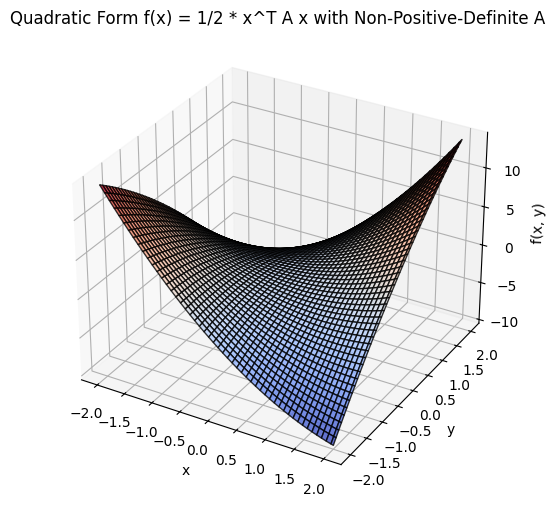

[[ 2  3]
 [ 3 -1]]


In [130]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define a symmetric matrix A that is NOT positive definite
A = np.array([[2, 3], [3, -1]])  

def quadratic_form(x, y, A):
    vec = np.array([x, y])
    return 0.5 * vec @ A @ vec

x_vals = np.linspace(-2, 2, 100)
y_vals = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.array([[quadratic_form(x, y, A) for x, y in zip(x_row, y_row)] for x_row, y_row in zip(X, Y)])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, edgecolor='k')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Quadratic Form f(x) = 1/2 * x^T A x with Non-Positive-Definite A')
plt.show()

print(A)

# Task 3 - COCO

In [19]:
import cocoex
import cocopp
import numpy as np
from scipy.optimize import minimize

# Algorithms to test
algorithms = {
    "Nelder-Mead": {"method": "Nelder-Mead"},
    "Powell": {"method": "Powell"},
    "L-BFGS-B": {"method": "L-BFGS-B"}, # limite memory BFGS
    "BFGS": {"method": "BFGS"},
    "CG": {"method": "CG"} # conjugate gradients
}

suite_name = "bbob"
budget_multiplier = 1  


for algo_name, algo_params in algorithms.items():

    print(f"Running: {algo_name}")

    
    output_folder = f"{algo_name.replace(' ', '_')}_on_bbob"
    suite = cocoex.Suite(suite_name, "", "")  
    observer = cocoex.Observer(suite_name, f"result_folder: {output_folder}, algorithm_name: {algo_name}")
    repeater = cocoex.ExperimentRepeater(budget_multiplier)
    minimal_print = cocoex.utilities.MiniPrint()

    while not repeater.done():
        for problem in suite:
            if repeater.done(problem):
                continue

            problem.observe_with(observer)

            x0 = repeater.initial_solution_proposal(problem)

            def objective(x):
                return problem(x)

            result = minimize(objective, x0, **algo_params)
            
            problem(result.x)
            repeater.track(problem)
            minimal_print(problem)

    print(f"Finished: {algo_name}")


Running: Nelder-Mead
COCO INFO: Results will be output to folder exdata/Nelder-Mead_on_bbob,-0001
2D 23h00:13
 f1||||||||||||||| f2.|||||||||||||| f3............... f4...............
 f5||||||||||||||| f6............... f7............... f8|||||||||||||||
 f9|||||||||||||||f10|||||||||||||||f11.||.|||||||||||f12|..|..||.|..|.|
f13....|.....|....f14|||||||||||||||f15...............f16...............
f17...............f18...............f19...........|...f20...............
f21|..|.....|...|.f22......|...|..|.f23...............f24...............
3D 23h00:14
 f1||||||||||||||| f2..|.|.|||.|.||| f3............... f4...............
 f5.||||||||||.||| f6............... f7............... f8.||||||||||||||
 f9|||||||||||||||f10.|.||..||||||.|f11.||...|..||.|.|f12.......|.......
f13...............f14||||||||||||||.f15...............f16...............
f17...............f18...............f19...............f20...............
f21..|............f22....|..........f23...............f24...............
5D

In [ ]:
import cocopp

folders = [
    "exdata/Nelder-Mead_on_bbob,-0001",
    "exdata/Powell_on_bbob,-0001",
    "exdata/L-BFGS-B_on_bbob,-0001",
    "exdata/BFGS_on_bbob,",
    "exdata/CG_on_bbob,"
]

cocopp.main(folders)

Post-processing (2+)
  Using 5 data sets:
    exdata/Nelder-Mead_on_bbob,-0001
    exdata/Powell_on_bbob,-0001
    exdata/L-BFGS-B_on_bbob,-0001
    exdata/BFGS_on_bbob,
    exdata/CG_on_bbob,

Post-processing (2+)
  loading data...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cocopp/pproc.py:1473: UserWarning: settings is an additional attribute.
  warnings.warn('%s is an additional attribute.' % (attrname))


  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/Nelder-Mead_on_bbob,-0001
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/Powell_on_bbob,-0001
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/L-BFGS-B_on_bbob,-0001
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/BFGS_on_bbob,
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/CG_on_bbob,
  Will generate output data in folder ppdata/Nelde_Powel_L-BFG_BFGS__CG_on_040423h1530
    this might take several minutes.
ECDF graphs per noise group...
Loading best algorithm data from refalgs/best2009-bbob.tar.gz ...
  using: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cocopp/refalgs/best2009-bbob.tar.gz
  done (Fri Apr  4 23:15:30 2025).
  done (Fri Apr  4 23:15:32 2025).
ECDF graphs per function group...
  done (Fri Apr  4 23:15:39 2025).

NameError: name 'sys' is not defined

In [24]:
import sys
sys.argv.extend(["-o", "my_output_folder"])

# Run cocopp post-processing
cocopp.main(folders)

Post-processing (2+)
  Using 5 data sets:
    exdata/Nelder-Mead_on_bbob,-0001
    exdata/Powell_on_bbob,-0001
    exdata/L-BFGS-B_on_bbob,-0001
    exdata/BFGS_on_bbob,
    exdata/CG_on_bbob,

Post-processing (2+)
  loading data...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cocopp/pproc.py:1473: UserWarning: settings is an additional attribute.
  warnings.warn('%s is an additional attribute.' % (attrname))


  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/Nelder-Mead_on_bbob,-0001
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/Powell_on_bbob,-0001
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/L-BFGS-B_on_bbob,-0001
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/BFGS_on_bbob,
  Data consistent according to consistency_check() in pproc.DataSet
  using: exdata/CG_on_bbob,
  Will generate output data in folder ppdata/Nelde_Powel_L-BFG_BFGS__CG_on_040423h1655
    this might take several minutes.
ECDF graphs per noise group...
Loading best algorithm data from refalgs/best2009-bbob.tar.gz ...
  using: /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cocopp/refalgs/best2009-bbob.tar.gz
  done (Fri Apr  4 23:16:55 2025).
  done (Fri Apr  4 23:16:57 2025).
ECDF graphs per function group...
  done (Fri Apr  4 23:17:04 2025).

DictAlg([(('Nelder-Mead_on_bbob,-0001', ''),
          [DataSet(Nelder-Mead_on_bbob,-0001 on f1 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f2 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f3 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f4 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f5 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f6 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f7 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f8 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f9 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f10 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f11 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f12 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0001 on f13 2-D, settings = ),
           DataSet(Nelder-Mead_on_bbob,-0